# Ham or Spam? — Live Demo & Lecture

## *From raw email text to a 99 % classifier in 60 minutes*

<br>

**Today's promise**

We start with raw, messy emails and end with a model that decides spam vs ham with **~98.9 % accuracy** — using only the techniques from the first three weeks of NLP: cleaning, Bag-of-Words, and Multinomial Naive Bayes.

**Learning objectives**

1. Apply a 5-step text-cleaning pipeline to real data.
2. Convert cleaned text to numerical vectors with `CountVectorizer`.
3. Train and cross-validate a `MultinomialNB` classifier.
4. Visualize what the model learned (top spam words, confusion matrix).
5. Use the model live on a custom email.

**Outline**

| # | Section | Time |
|---|---|---|
| 0 | Setup & imports | 5 min |
| 1 | Load and explore the data | 10 min |
| 2 | Text cleaning pipeline (5 steps) | 20 min |
| 3 | Bag of Words vectorization | 10 min |
| 4 | Multinomial Naive Bayes — theory + training | 15 min |
| 5 | Diagnose the model (top words, confusion matrix) | 10 min |
| 6 | Compare to TF-IDF and Logistic Regression | 10 min |
| 7 | **Live demo** — paste your own email | 5 min |
| 8 | Wrap-up + next steps | 5 min |

---

# 0 · Setup

We use **NLTK** for stop-words and lemmatization, **scikit-learn** for vectorization and modeling, **pandas** for the dataframe, and **matplotlib / wordcloud** for visualizations.

> 💡 **Pro tip for live demos** — run this cell *before* the audience arrives. NLTK downloads can take 30 s and break the rhythm.

In [10]:
# !pip install -q nltk scikit-learn pandas matplotlib seaborn wordcloud

import string
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay,
)

# Download NLTK resources (idempotent — safe to run multiple times)
for pkg in ['stopwords', 'punkt', 'punkt_tab', 'wordnet', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

sns.set_theme(style='whitegrid', context='talk')
print('Setup complete ✓')

ModuleNotFoundError: No module named 'seaborn'

---

# 1 · Load and explore the data

The dataset is hosted by Le Wagon — a CSV of ~5 700 emails labeled `spam` (1) or `ham` (0).

**URL** — `https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/10-Natural-Language-Processing/ham_spam_emails.csv`

Before training anything, we always **look at the data**: shape, class balance, sample texts, length statistics.

In [11]:
URL = ('https://wagon-public-datasets.s3.amazonaws.com/'
       '05-Machine-Learning/10-Natural-Language-Processing/ham_spam_emails.csv')

df = pd.read_csv(URL)
print(f'Shape: {df.shape}')
df.head()

Shape: (5728, 2)


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


Class counts:
  Ham  (0):  4360 (76.1%)
  Spam (1):  1368 (23.9%)


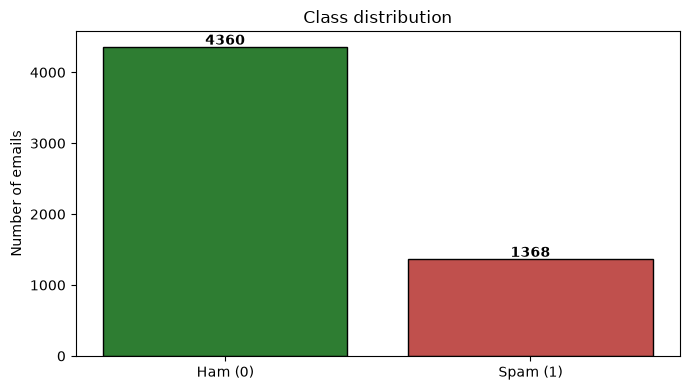

In [12]:
# Class balance — how skewed is the dataset?
counts = df['spam'].value_counts().sort_index()
print('Class counts:')
print(f'  Ham  (0): {counts[0]:>5} ({counts[0] / len(df):.1%})')
print(f'  Spam (1): {counts[1]:>5} ({counts[1] / len(df):.1%})')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['Ham (0)', 'Spam (1)'], counts.values,
       color=['#2e7d32', '#c0504d'], edgecolor='black')
ax.set_title('Class distribution')
ax.set_ylabel('Number of emails')
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

> 🩺 **What to ask out loud** — *Is the class balance roughly 24 % spam / 76 % ham acceptable?* For accuracy as the metric, yes. If the imbalance were 99 / 1 we would need precision/recall instead.

Now eyeball a sample email of each class:

In [13]:
def show_sample(df, label, n=1):
    text = df[df.spam == label].iloc[0].text
    name = 'SPAM' if label else 'HAM'
    print(f'─── {name} sample ' + '─' * 50)
    print(text[:500] + ('...' if len(text) > 500 else ''))

show_sample(df, 1)
print()
show_sample(df, 0)

─── SPAM sample ──────────────────────────────────────────────────
Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , stylish statlonery and outstanding website  will make the task much easier .  we do not promise that havinq ordered a iogo your  company will automaticaily become a world ieader : it isguite ciear that  without good products , effective business organization and practicable aim it  will be hotat nowad...

─── HAM sample ──────────────────────────────────────────────────
Subject: hello guys ,  i ' m " bugging you " for your completed questionnaire and for a one - page  bio / statement on your thoughts on " business edu and the new economy " . if  my records are incorrect please re - ship your responses to me . i want to  put everything together next week so that i can ship it back to everyone .  the questionnaire is attached a

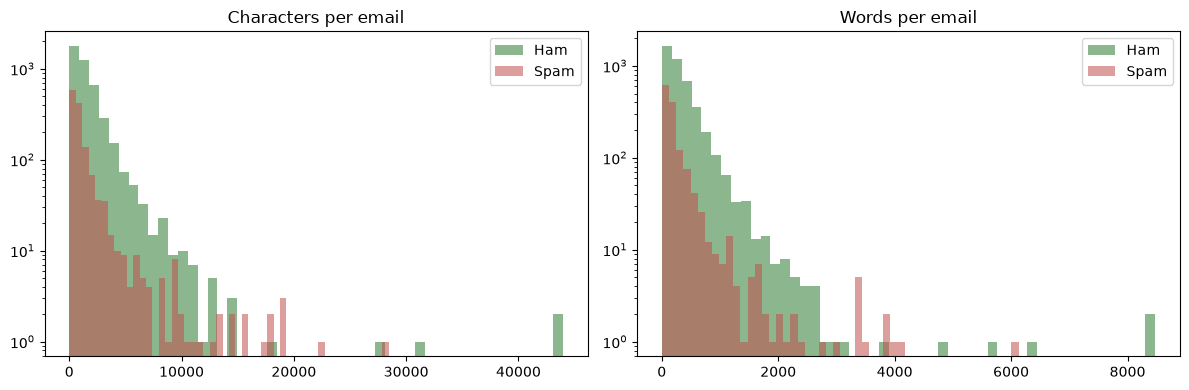

In [14]:
# Length distribution — useful for setting maxlen if we move to deep learning
df['n_chars'] = df.text.str.len()
df['n_words'] = df.text.str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes,
                          ['n_chars', 'n_words'],
                          ['Characters per email', 'Words per email']):
    for label, color in [(0, '#2e7d32'), (1, '#c0504d')]:
        ax.hist(df[df.spam == label][col],
                bins=50, alpha=0.55, color=color,
                label='Ham' if label == 0 else 'Spam')
    ax.set_title(title); ax.set_yscale('log'); ax.legend()
plt.tight_layout(); plt.show()

---

# 2 · The text-cleaning pipeline

Raw text is messy. We apply five standard steps:

```
Raw → remove punctuation → lowercase → remove numbers → remove stop-words → lemmatize → CLEAN TEXT
```

> 🎯 **Big idea** — *standardize the vocabulary* so that `Hello!`, `hello`, and `HELLO` all become the same token. Without this, a Bag-of-Words model would treat them as three different features.

We will build each step as a small function and add a column to `df` so we can debug along the way.

## 2.1 — Remove punctuation

Why? Punctuation is mostly noise for a Bag-of-Words classifier. `"free!"`, `"free,"`, `"free."` should all map to the same token `free`.

We replace each punctuation symbol with a space (not an empty string) so that `"hello,world"` becomes `"hello world"` rather than `"helloworld"`.

In [15]:
def remove_punctuation(text: str) -> str:
    for p in string.punctuation:
        text = text.replace(p, ' ')
    return text

df['clean_text'] = df.text.apply(remove_punctuation)

print(string.punctuation)
print()
print('Before:', df.text.iloc[0][:120])
print('After :', df.clean_text.iloc[0][:120])

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~

Before: Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full 
After : Subject  naturally irresistible your corporate identity  lt is really hard to recollect a company   the  market is full 


## 2.2 — Lowercase

Why? `Free`, `FREE`, and `free` should all be the same word.

> ⚠️ **Pitfall** — for some tasks (named-entity recognition, code analysis) lowercasing destroys signal. Always context-dependent.

In [16]:
df['clean_text'] = df.clean_text.str.lower()
df.clean_text.iloc[0][:120]

'subject  naturally irresistible your corporate identity  lt is really hard to recollect a company   the  market is full '

## 2.3 — Remove numbers

Why? In spam classification, raw digits (`2`, `42`, `12345`) rarely carry class signal. The *pattern* of "a digit appears" might matter, but our BoW model would otherwise create one feature per number.

> 💡 In *fraud* detection you might keep them. Always re-evaluate per task.

In [17]:
def remove_numbers(text: str) -> str:
    return ''.join(c for c in text if not c.isdigit())

df['clean_text'] = df.clean_text.apply(remove_numbers)
df.clean_text.iloc[0][:120]

'subject  naturally irresistible your corporate identity  lt is really hard to recollect a company   the  market is full '

## 2.4 — Remove stop-words

Stop-words (`the`, `a`, `is`, `on`, …) are extremely common but carry little discriminative information. NLTK ships a built-in English list of ~180 words.

> 🩺 **When to keep stop-words** — sentiment analysis (`not good`), seq2seq tasks, modern transformer models that handle them via attention. For a Naive Bayes BoW classifier, dropping them helps.

In [18]:
stop_words = set(stopwords.words('english'))
print(f'{len(stop_words)} English stop-words. First 20:')
print(sorted(stop_words)[:20])

NameError: name 'stopwords' is not defined

In [19]:
def remove_stopwords(text: str) -> list[str]:
    return [w for w in word_tokenize(text) if w not in stop_words]

df['clean_text'] = df.clean_text.apply(remove_stopwords)
df.clean_text.iloc[0][:15]

NameError: name 'word_tokenize' is not defined

## 2.5 — Lemmatize

Lemmatization reduces words to their dictionary form: `running → run`, `studies → study`, `better → good`. The NLTK `WordNetLemmatizer` uses the WordNet database — so the output is always a real word.

> 📊 **Stemming vs Lemmatization** — *stemming* (rule-based truncation) gives `studi`; *lemmatization* gives `study`. Lemmatization is slower but more accurate.

Finally we **join the tokens back into a single string** so that `CountVectorizer` can split them again (it expects a string per document).

In [ ]:
lemmatizer = WordNetLemmatizer()

def lemma(tokens: list[str]) -> str:
    return ' '.join(lemmatizer.lemmatize(w) for w in tokens)

df['clean_text'] = df.clean_text.apply(lemma)
df[['text', 'clean_text']].head(3)

### 2.6 — Side-by-side comparison

Let's look at one email before and after cleaning — the difference is dramatic.

In [ ]:
i = 5
print('─── BEFORE ' + '─' * 60)
print(df.text.iloc[i][:400])
print('\n─── AFTER  ' + '─' * 60)
print(df.clean_text.iloc[i][:400])

---

# 3 · Bag of Words — turning words into numbers

Our cleaned text is still strings. Machine-learning models need numbers.

**Bag of Words (BoW)** represents each document as a vector of **word counts**. If the vocabulary has 30 000 words, every email becomes a 30 000-dimensional vector — but mostly zeros (sparse).

> 🎒 **The bag analogy** — imagine throwing every word of the email into a bag and counting. *Order is lost*. The sentence "dog bites man" and "man bites dog" look the same to BoW.

`scikit-learn` does the heavy lifting via **`CountVectorizer`**.

In [ ]:
vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(df.clean_text)

print(f'Shape of X_bow: {X_bow.shape}')
print(f'Type          : {type(X_bow).__name__} (sparse matrix)')
print(f'Density       : {X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1]):.4%}')

**Sparse matrix** — only the non-zero values are stored. With 99.8% zeros, this saves enormous memory.

Let's peek at the vocabulary and at one row:

In [ ]:
vocab = vectorizer.get_feature_names_out()
print(f'Vocab size: {len(vocab):,}')
print(f'First 10 words : {list(vocab[:10])}')
print(f'Random sample  : {list(np.random.choice(vocab, 8, replace=False))}')

In [ ]:
# Look at one document's BoW vector — show only the non-zero entries
doc_id = 0
row = X_bow[doc_id].toarray()[0]
nonzero_idx = np.nonzero(row)[0]

pairs = sorted(zip(vocab[nonzero_idx], row[nonzero_idx]),
               key=lambda x: -x[1])[:15]
print(f'Top 15 tokens in email #{doc_id}:')
for w, c in pairs:
    print(f'  {w:20s} → {c}')

---

# 4 · Multinomial Naive Bayes — the model

## 4.1 Intuition

**Bayes' rule** lets us flip a conditional probability:

$$P(\text{spam} \mid \text{email}) = \frac{P(\text{email} \mid \text{spam}) \, P(\text{spam})}{P(\text{email})}$$

Computing $P(\text{email} \mid \text{spam})$ for an arbitrary email is impossible — so we **assume independence** between the words (the "naive" part):

$$P(\text{email} \mid \text{spam}) \approx \prod_{i} P(w_i \mid \text{spam})$$

Each word probability $P(w_i \mid \text{spam})$ is just the relative frequency of $w_i$ in spam emails. Cheap to estimate, cheap to predict.

**Why "multinomial"?** We model word *counts* (multinomial distribution), not just presence/absence (Bernoulli) or continuous values (Gaussian).

## 4.2 Strengths and weaknesses

| ✅ Strengths | ⚠️ Weaknesses |
|---|---|
| Extremely fast to train and predict | Ignores word order |
| Works well on sparse high-dim data | Strong (wrong) independence assumption |
| Strong baseline for text classification | Probabilities themselves are poorly calibrated |
| Interpretable per-word probabilities | Beaten by Logistic Regression on many tasks |

## 4.3 Train and cross-validate

We use 5-fold cross-validation — train on 80 %, evaluate on 20 %, repeat 5 times, average.

In [ ]:
from sklearn.model_selection import cross_validate

cv = cross_validate(
    MultinomialNB(),
    X_bow, df.spam,
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    cv=5,
    n_jobs=-1,
)

print('5-fold cross-validation scores:')
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    scores = cv[f'test_{metric}']
    print(f'  {metric:10s}: {scores.mean():.4f}  '
          f'(±{scores.std():.4f})')

🎉 **~99 % accuracy** with a model that took milliseconds to train.

But accuracy alone is misleading on imbalanced data. Let's look at precision/recall too:
- **Precision** — *of the emails I called spam, how many really were?*
- **Recall** — *of the spam emails out there, how many did I catch?*

For a spam filter we usually care about **high precision** (false positives are bad — important ham lost to the spam folder).

---

# 5 · Diagnose the model

## 5.1 Train once on a hold-out split for plots and inspection

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df.clean_text, df.spam, test_size=0.2,
    random_state=42, stratify=df.spam,
)

vectorizer = CountVectorizer()
X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow  = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_bow, y_train)

y_pred = model.predict(X_test_bow)
print(f'Hold-out accuracy: {accuracy_score(y_test, y_pred):.4f}\n')
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

## 5.2 Confusion matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['ham', 'spam']).plot(
    ax=ax, cmap='Blues', colorbar=False, values_format='d',
)
ax.set_title('Confusion matrix — hold-out test set')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True negatives  (ham → ham )  : {tn}')
print(f'False positives (ham → spam)  : {fp}   ← important emails lost')
print(f'False negatives (spam → ham)  : {fn}   ← spam reaching inbox')
print(f'True positives  (spam → spam) : {tp}')

## 5.3 Top words per class — what did the model learn?

MultinomialNB exposes `feature_log_prob_` — the log-probability of each word given each class. The biggest gap between the two classes tells us which words are **most diagnostic**.

In [ ]:
vocab = np.array(vectorizer.get_feature_names_out())
log_ham, log_spam = model.feature_log_prob_   # shape (n_vocab,)

spam_minus_ham = log_spam - log_ham
top_spam = np.argsort(spam_minus_ham)[-20:][::-1]
top_ham  = np.argsort(spam_minus_ham)[:20]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(vocab[top_spam][::-1], spam_minus_ham[top_spam][::-1],
             color='#c0504d')
axes[0].set_title('Top 20 SPAM indicators'); axes[0].set_xlabel('log P(w|spam) − log P(w|ham)')
axes[1].barh(vocab[top_ham], -spam_minus_ham[top_ham], color='#2e7d32')
axes[1].set_title('Top 20 HAM indicators');  axes[1].set_xlabel('log P(w|ham) − log P(w|spam)')
plt.tight_layout(); plt.show()

> 👀 **Class discussion** — *do the top spam words match your intuition?* You should see words like `free`, `click`, `money`, `offer`, `winner`, `account`. These are the classic spam signals.

## 5.4 Word clouds — bonus visualization

In [ ]:
try:
    from wordcloud import WordCloud

    ham_text  = ' '.join(df[df.spam == 0].clean_text)
    spam_text = ' '.join(df[df.spam == 1].clean_text)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, text, title, color in [
        (axes[0], ham_text,  'HAM word cloud',  'Greens'),
        (axes[1], spam_text, 'SPAM word cloud', 'Reds'),
    ]:
        wc = WordCloud(width=800, height=500, background_color='white',
                        colormap=color, max_words=80).generate(text)
        ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
        ax.set_title(title, fontsize=18, fontweight='bold')
    plt.tight_layout(); plt.show()
except ImportError:
    print('wordcloud is not installed — skip with: pip install wordcloud')

---

# 6 · Compare to TF-IDF and Logistic Regression

Two natural follow-up questions:

1. **Vectorization** — does `TfidfVectorizer` (which down-weights common words) beat `CountVectorizer`?
2. **Model** — does `LogisticRegression` beat `MultinomialNB`?

Let's measure all four combinations on the same 5-fold CV.

In [ ]:
from sklearn.pipeline import Pipeline

configs = {
    'BoW + NB':       Pipeline([('vec', CountVectorizer()), ('clf', MultinomialNB())]),
    'TF-IDF + NB':    Pipeline([('vec', TfidfVectorizer()),  ('clf', MultinomialNB())]),
    'BoW + LogReg':   Pipeline([('vec', CountVectorizer()), ('clf', LogisticRegression(max_iter=1000))]),
    'TF-IDF + LogReg':Pipeline([('vec', TfidfVectorizer()),  ('clf', LogisticRegression(max_iter=1000))]),
}

results = {}
for name, pipe in configs.items():
    cv = cross_validate(pipe, df.clean_text, df.spam,
                         scoring=['accuracy', 'precision', 'recall', 'f1'],
                         cv=5, n_jobs=-1)
    results[name] = {m: cv[f'test_{m}'].mean() for m in ['accuracy', 'precision', 'recall', 'f1']}

comp = pd.DataFrame(results).T.round(4)
comp

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
comp.plot(kind='bar', ax=ax, edgecolor='black',
          colormap='Set2', width=0.8)
ax.set_ylim(0.93, 1.0)
ax.set_title('Model + Vectorizer comparison — 5-fold CV')
ax.set_ylabel('Score'); ax.legend(loc='lower right')
plt.xticks(rotation=15, ha='right')
plt.tight_layout(); plt.show()

> 🩺 **Discuss** — Logistic Regression usually edges out Naive Bayes here, but the gap is small. **NB wins on training speed and simplicity** — a classic case where the right answer depends on context.

---

# 7 · 🎬 Live demo — classify a custom email

We bundle the full pipeline into a function. Paste **any text** and get an instant prediction with a confidence score.

> 🎤 **Presenter tip** — invite the audience to type a fake spam ("FREE iPhone! Click here!") and a fake ham ("Hi mom, see you Sunday").

In [ ]:
# Train once on the full data so the demo is as strong as possible
final_vec = CountVectorizer()
X_full = final_vec.fit_transform(df.clean_text)
final_model = MultinomialNB().fit(X_full, df.spam)

def clean(text: str) -> str:
    """The same 5-step pipeline applied to a fresh email."""
    text = remove_punctuation(text)
    text = text.lower()
    text = remove_numbers(text)
    tokens = [w for w in word_tokenize(text) if w not in stop_words]
    return ' '.join(lemmatizer.lemmatize(t) for t in tokens)

def predict(email: str) -> dict:
    cleaned = clean(email)
    vec = final_vec.transform([cleaned])
    proba = final_model.predict_proba(vec)[0]
    label = 'SPAM 🚨' if proba[1] > 0.5 else 'HAM ✅'
    return {
        'verdict':    label,
        'P(spam)':    f'{proba[1]:.2%}',
        'P(ham)':     f'{proba[0]:.2%}',
        'cleaned':    cleaned[:120] + ('…' if len(cleaned) > 120 else ''),
    }

In [ ]:
# ── Example 1 — obvious spam ──────────────────────
email_1 = """
CONGRATULATIONS!!! You have been selected to receive a FREE iPhone 15.
Click here NOW to claim your prize before it expires! Limited offer.
Send your bank details to claim. Don't miss out!
"""
predict(email_1)

In [ ]:
# ── Example 2 — clear ham ──────────────────────────
email_2 = """
Hi team, attached is the agenda for tomorrow's meeting.
Please review section 3 and bring your notes. Thanks!
"""
predict(email_2)

In [ ]:
# ── Example 3 — type your own here ─────────────────
my_email = """
Write any email here and re-run the cell to see the classifier's verdict.
"""
predict(my_email)

## 7.1 Why was each classified that way?

Quick interpretation: show which words pushed the verdict.

In [ ]:
def explain(email: str, top_k: int = 8):
    cleaned = clean(email)
    tokens = cleaned.split()
    word_idx = {w: i for i, w in enumerate(final_vec.get_feature_names_out())}
    log_ham, log_spam = final_model.feature_log_prob_
    contributions = []
    for t in set(tokens):
        if t in word_idx:
            i = word_idx[t]
            contributions.append((t, log_spam[i] - log_ham[i]))
    contributions.sort(key=lambda x: -abs(x[1]))
    print(f'Top {top_k} discriminating words in this email:')
    for w, score in contributions[:top_k]:
        arrow = '↑ spam' if score > 0 else '↓ ham '
        print(f'  {w:18s}  {arrow}   weight = {score:+.2f}')

explain(email_1)
print()
explain(email_2)

---

# 8 · Wrap-up

## What we built today

1. A 5-step **text-cleaning pipeline** (punctuation, lowercase, digits, stop-words, lemmatization).
2. A **Bag-of-Words** representation with `CountVectorizer`.
3. A **Multinomial Naive Bayes** classifier reaching ~99 % accuracy.
4. A diagnostic toolkit: confusion matrix, top-word inspection, word clouds.
5. A four-way comparison (BoW vs TF-IDF, NB vs LogReg).
6. A working **live demo** that classifies any email on the fly.

## The seven things to remember

1. Cleaning standardizes the vocabulary — but every step is task-dependent.
2. Bag of Words loses order; for spam classification that's enough.
3. `CountVectorizer` produces a sparse matrix — never `.toarray()` on production data.
4. Naive Bayes is a strong, fast baseline for text classification.
5. Accuracy alone is misleading on imbalanced data — look at precision/recall.
6. The confusion matrix tells you *which kind* of error matters.
7. Always compare to at least one alternative (here: TF-IDF + LogReg).

## Next steps

- **Hyper-parameter tuning** — `min_df`, `max_df`, `ngram_range=(1,2)` on the vectorizer; smoothing `alpha` on NB.
- **Better features** — character n-grams, TF-IDF, sub-word tokens.
- **Better models** — Logistic Regression, SVM, Gradient Boosting.
- **Modern models** — fine-tune a small transformer (`distilbert-base-uncased`) for the same task — expect 99.5 %+.
- **Production** — pickle the pipeline, expose a FastAPI endpoint, monitor drift.

---

🎉 **End of lecture — questions?**